# Multi-Modal Content-Based Music Recommendation Engine
### Fusing Full-Song Acoustic Embeddings, Multilingual Lyrics, Mood & Vibe Descriptors, and Contextual Guards

This notebook implements an industrial-grade **multi-modal content-based recommendation engine** for 10,000 Spotify songs. We demonstrate:

1. **Sub-Millisecond Pre-computed Top-250 Lookups:** Querying [`knn_audio_top250.parquet`](file:///home/esstee/projects/top10k/music-prediction/data/similarity/knn_audio_top250.parquet), [`knn_lyric_top250.parquet`](file:///home/esstee/projects/top10k/music-prediction/data/similarity/knn_lyric_top250.parquet), [`knn_mood_top250.parquet`](file:///home/esstee/projects/top10k/music-prediction/data/similarity/knn_mood_top250.parquet), and [`knn_combined_top250.parquet`](file:///home/esstee/projects/top10k/music-prediction/data/similarity/knn_combined_top250.parquet).
2. **Dynamic Multi-Modal Interactive Engine:** Blending acoustic timbre, lyrical narrative, unified mood & context (83-D), genre style, and temporal era with customizable weights.
3. **Contextual Constraints & Diversity Guards:** Enforcing same-language, same-decade filtering, or artist diversity penalties.
4. **Visual Playlist Journey on 2D Latent Manifold:** Visualizing smooth transition paths across the 2D multimodal latent space.


## 1. Setup & Data Loading

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Robust path resolution
if Path('data/metadata/songs.parquet').exists():
    DATA_DIR = Path('data')
elif Path('../data/metadata/songs.parquet').exists():
    DATA_DIR = Path('../data')
elif Path('/kaggle/input/spotify-10k-music-features').exists():
    DATA_DIR = Path('/kaggle/input/spotify-10k-music-features')
else:
    raise FileNotFoundError("Dataset path not found.")

songs = pd.read_parquet(DATA_DIR / 'metadata' / 'songs.parquet')
lang_id = pd.read_parquet(DATA_DIR / 'features' / 'lyric' / 'language_id.parquet')
derived = pd.read_parquet(DATA_DIR / 'features' / 'metadata' / 'derived.parquet')

# Load L2-Normalized Feature Arrays
def l2_norm(arr):
    norms = np.linalg.norm(arr, axis=1, keepdims=True)
    return arr / np.maximum(norms, 1e-12)

# 1. Acoustic Representation (1664-D: CLAP + MERT + VGGish)
clap = np.load(DATA_DIR / 'embeddings' / 'audio' / 'clap_512d.npy')
mert = np.load(DATA_DIR / 'embeddings' / 'audio' / 'mert_330m_embeddings_1024d.npy')
vgg  = np.load(DATA_DIR / 'embeddings' / 'audio' / 'vggish_embeddings_128d.npy')
audio_norm = l2_norm(np.concatenate([l2_norm(clap), l2_norm(mert), l2_norm(vgg)], axis=1))

# 2. Lyric Representation (2048-D: Harrier-0.6B + E5-Large)
harrier = np.load(DATA_DIR / 'embeddings' / 'lyric' / 'harrier_embeddings_1024d.npy')
e5_lyric = np.load(DATA_DIR / 'embeddings' / 'lyric' / 'multilingual_e5_large_1024d.npy')
has_lyrics = (np.linalg.norm(harrier, axis=1, keepdims=True) > 1e-6).astype(np.float32)
lyric_norm = l2_norm(np.concatenate([l2_norm(harrier), l2_norm(e5_lyric)], axis=1)) * has_lyrics

# 3. Unified Mood & Context Representation (83-D: Genre 40% + Spotify 30% + Temporal 15% + Vocal DSP 15%)
# Evaluated via LOGO ablation: GoEmotions (36-D) dropped to remove non-English zero-padding bias;
# Genre Hybrid (50-D) and Temporal Context (10-D) added as stylistic and era anchors.
spotify_11d = np.load(DATA_DIR / 'embeddings' / 'metadata' / 'spotify_audio_11d.npy')
vocal_12d   = np.load(DATA_DIR / 'embeddings' / 'metadata' / 'vocal_dsp_12d.npy')
genre_50d   = np.load(DATA_DIR / 'embeddings' / 'metadata' / 'genre_hybrid_50d.npy')
temporal_10d = np.load(DATA_DIR / 'embeddings' / 'metadata' / 'temporal_collab_10d.npy')

mood_blocks = [
    np.sqrt(0.40) * l2_norm(genre_50d),
    np.sqrt(0.30) * l2_norm(spotify_11d),
    np.sqrt(0.15) * l2_norm(temporal_10d),
    np.sqrt(0.15) * l2_norm(vocal_12d)
]
mood_norm = l2_norm(np.concatenate(mood_blocks, axis=1))

# 4. Genre Style Representation (50-D: 17-D Main + 17-D Sub Rollup + 16-D Latent SVD)
genre_norm = l2_norm(genre_50d)

# 5. Temporal & Collaboration Context (10-D)
temporal_norm = l2_norm(temporal_10d)

print(f"Loaded representations for {len(songs):,} songs:")
print(f"  • Audio Embedding Dimension:          {audio_norm.shape[1]}-D")
print(f"  • Lyric Embedding Dimension:          {lyric_norm.shape[1]}-D")
print(f"  • Unified Mood & Context Dimension:   {mood_norm.shape[1]}-D")
print(f"  • Genre Hybrid Dimension:             {genre_norm.shape[1]}-D")
print(f"  • Temporal & Context Dimension:       {temporal_norm.shape[1]}-D")


Loaded representations for 10,000 songs:
  • Audio Embedding Dimension:          1664-D
  • Lyric Embedding Dimension:          2048-D
  • Unified Mood & Context Dimension:   83-D
  • Genre Hybrid Dimension:             50-D
  • Temporal & Context Dimension:       10-D


## 2. Fast-Path: Querying Pre-Computed Top-250 Matrices
For latency-critical applications, query the static Top-250 Parquet graphs directly ($O(1)$ sub-millisecond lookup).


In [2]:
# Load pre-computed graph files
knn_combined = pd.read_parquet(DATA_DIR / 'similarity' / 'knn_combined_top250.parquet')
knn_mood = pd.read_parquet(DATA_DIR / 'similarity' / 'knn_mood_top250.parquet')

seed_idx = 42
seed_title = songs.iloc[seed_idx]['track_name']
seed_artist = songs.iloc[seed_idx]['artist_names']

print(f"Seed Track [{seed_idx}]: '{seed_title}' by {seed_artist}\n")

print("Top 10 Instant Recommendations from Pre-computed Combined Top-250 Graph:")
for nb_idx, sim in zip(knn_combined.iloc[seed_idx]['top250_neighbor_indices'][:10], knn_combined.iloc[seed_idx]['top250_similarities'][:10]):
    print(f"  - '{nb_idx}' -> '{songs.iloc[nb_idx]['track_name']}' by {songs.iloc[nb_idx]['artist_names']} (Similarity: {sim:.3f})")


Seed Track [42]: 'Messy' by Lola Young

Top 10 Instant Recommendations from Pre-computed Combined Top-250 Graph:
  - '7850' -> 'Messy' by Lola Young (Similarity: 0.982)
  - '4469' -> 'Not Like That Anymore' by Lola Young (Similarity: 0.905)
  - '5364' -> 'Blowing Smoke' by Gracie Abrams (Similarity: 0.883)
  - '203' -> 'Austin (Boots Stop Workin')' by Dasha (Similarity: 0.878)
  - '8456' -> 'messy' by Łaszewo (Similarity: 0.878)
  - '6' -> 'That’s So True' by Gracie Abrams (Similarity: 0.877)
  - '2334' -> 'Cry' by Benson Boone (Similarity: 0.876)
  - '7705' -> 'Tough Love' by Gracie Abrams (Similarity: 0.874)
  - '7683' -> 'Not At This Party' by Dasha (Similarity: 0.874)
  - '2216' -> 'Dive' by Olivia Dean (Similarity: 0.871)


## 3. Dynamic Multi-Modal Recommendation Function
Computes weighted cosine similarities across all 5 representation pillars with contextual guardrails:

$$\text{Sim}_{\text{Total}} = w_a \cdot S_{\text{audio}} + w_l \cdot S_{\text{lyric}} + w_m \cdot S_{\text{mood}} + w_g \cdot S_{\text{genre}} + w_t \cdot S_{\text{temporal}}$$


In [3]:
def recommend_songs(
    seed_idx: int,
    top_k: int = 5,
    audio_weight: float = 0.38,
    lyric_weight: float = 0.35,
    mood_weight: float = 0.15,
    genre_weight: float = 0.08,
    temporal_weight: float = 0.04,
    same_language_only: bool = False,
    same_decade_only: bool = False,
    penalize_same_artist: bool = True
):
    """
    Recommends top_k songs based on weighted multimodal similarity.
    
    Instrumental Fallback Behavior:
    If the seed track has no lyrics (has_lyrics == 0), s_lyric falls back to s_audio.
    This intentionally re-allocates the lyric weight to acoustic similarity, preventing
    instrumental songs from being penalized by zero-vector dot products.
    """
    s_audio    = audio_norm @ audio_norm[seed_idx]
    
    # Instrumental fallback: if seed has no lyrics, route lyric weight to audio
    if has_lyrics[seed_idx, 0] > 0:
        s_lyric = lyric_norm @ lyric_norm[seed_idx]
    else:
        s_lyric = s_audio  # Fallback to acoustic similarity
        
    s_mood     = mood_norm @ mood_norm[seed_idx]
    s_genre    = genre_norm @ genre_norm[seed_idx]
    s_temporal = temporal_norm @ temporal_norm[seed_idx]
    
    total_sim = (
        audio_weight * s_audio +
        lyric_weight * s_lyric +
        mood_weight  * s_mood +
        genre_weight * s_genre +
        temporal_weight * s_temporal
    )
    
    # Contextual Guard 1: Language filter
    if same_language_only:
        seed_lang = lang_id.iloc[seed_idx]['primary_language']
        total_sim[lang_id['primary_language'] != seed_lang] = -1e9
        
    # Contextual Guard 2: Decade filter
    if same_decade_only:
        seed_decade = derived.iloc[seed_idx]['release_decade']
        total_sim[derived['release_decade'] != seed_decade] = -1e9
        
    # Contextual Guard 3: Artist diversity penalty
    if penalize_same_artist:
        seed_artists = set(str(songs.iloc[seed_idx]['artist_names']).lower().split(','))
        for idx in range(len(songs)):
            if idx == seed_idx:
                continue
            cand_artists = set(str(songs.iloc[idx]['artist_names']).lower().split(','))
            if bool(seed_artists & cand_artists):
                total_sim[idx] *= 0.85  # Apply 15% penalty to foster musical discovery
                
    # Mask self
    total_sim[seed_idx] = -1e9
    
    top_indices = np.argsort(total_sim)[-top_k:][::-1]
    
    results = songs.iloc[top_indices][['track_name', 'artist_names', 'popularity', 'main_genres', 'release_date']].copy()
    results['similarity_score'] = np.round(total_sim[top_indices], 4)
    results['audio_sim'] = np.round(s_audio[top_indices], 4)
    results['mood_sim'] = np.round(s_mood[top_indices], 4)
    results['genre_sim'] = np.round(s_genre[top_indices], 4)
    
    return results

# Test recommendation on Song 653
seed_idx = 653
print("--- Recommendations for Seed Track:")
print(f"'{songs.iloc[seed_idx]['track_name']}' by {songs.iloc[seed_idx]['artist_names']} - pop:{songs.iloc[seed_idx]['popularity']} year:{songs.iloc[seed_idx]['release_date']} ---")
# genres and sub-genres of seed track
print(f"Main Genres: {songs.iloc[seed_idx]['main_genres']}")
print(f"Sub Genres: {songs.iloc[seed_idx]['artist_genres']}")

print("\nDefault Weights: audio=0.38, lyric=0.35, mood=0.15, genre=0.08, temporal=0.04,\nsame_language_only=False, same_decade_only=False, penalize_same_artist=True")
print("Top 10 Recommendations (Default Weights)")

display(recommend_songs(seed_idx, top_k=10))

print("\n Custom Weights: audio=0.2, lyric=0.3, mood=0.3, genre=0.1, temporal=0.1,\nsame_language_only=False, same_decade_only=False, penalize_same_artist=False")
print("Top 10 Recommendations (Custom Weights)")

display(recommend_songs(seed_idx, top_k=10, audio_weight=0.2, lyric_weight=0.3, mood_weight=0.3, genre_weight=0.1, temporal_weight=0.1, same_language_only=False, same_decade_only=False, penalize_same_artist=False))


--- Recommendations for Seed Track:
'Billie Jean' by Michael Jackson - pop:83 year:1982-11-30 ---
Main Genres: Blues, R&B
Sub Genres: r&b, soul

Default Weights: audio=0.38, lyric=0.35, mood=0.15, genre=0.08, temporal=0.04,
same_language_only=False, same_decade_only=False, penalize_same_artist=True
Top 10 Recommendations (Default Weights)


,track_name,artist_names,popularity,main_genres,release_date,similarity_score,audio_sim,mood_sim,genre_sim
5307,Never Too Much,Luther Vandross,74,"Blues, R&B",1981-07-23,0.8771,0.9189,0.9345,0.9805
8471,"You're The First, The Last, My Everything - Edit",Barry White,71,"Blues, Pop, R&B",1988-09-12,0.8666,0.9346,0.8934,0.8831
7304,Part-Time Lover,Stevie Wonder,72,"Blues, Pop, R&B",1985-09-13,0.8582,0.8959,0.9282,0.8930
3526,"Signed, Sealed, Delivered (I'm Yours)",Stevie Wonder,76,"Blues, Pop, R&B",1970-08-07,0.8551,0.8875,0.9360,0.8930
7994,Let's Get It On,Marvin Gaye,71,"Blues, Pop, R&B",1973-08-28,0.8537,0.8960,0.8898,0.8982
6339,Sir Duke,Stevie Wonder,73,"Blues, Pop, R&B",1976-09-28,0.8502,0.9160,0.8995,0.8930
7064,Use Me,Bill Withers,72,"Blues, R&B",1972-05-01,0.8456,0.8382,0.9759,0.9853
864,Lovely Day,Bill Withers,82,"Blues, R&B",1977-10-29,0.8451,0.8616,0.9298,0.9853
7627,"Can't Get Enough Of Your Love, Babe",Barry White,72,"Blues, Pop, R&B",1974-02-15,0.8438,0.8728,0.8802,0.8831
3579,Sexual Healing,Marvin Gaye,76,"Blues, Pop, R&B",1982-10-01,0.8427,0.8829,0.9471,0.8982



 Custom Weights: audio=0.2, lyric=0.3, mood=0.3, genre=0.1, temporal=0.1,
same_language_only=False, same_decade_only=False, penalize_same_artist=False
Top 10 Recommendations (Custom Weights)


,track_name,artist_names,popularity,main_genres,release_date,similarity_score,audio_sim,mood_sim,genre_sim
3570,P.Y.T. (Pretty Young Thing),Michael Jackson,76,"Blues, R&B",1982-11-30,0.9180,0.9530,0.9953,1.0000
1532,Beat It,Michael Jackson,80,"Blues, R&B",1982-11-30,0.9006,0.8851,0.9866,1.0000
1920,Don't Stop 'Til You Get Enough,Michael Jackson,79,"Blues, R&B",1979-08-10,0.9003,0.9438,0.9532,1.0000
1534,Rock with You - Single Version,Michael Jackson,80,"Blues, R&B",1979-08-10,0.8966,0.9236,0.9467,1.0000
5307,Never Too Much,Luther Vandross,74,"Blues, R&B",1981-07-23,0.8918,0.9189,0.9345,0.9805
3044,The Way You Make Me Feel - 2012 Remaster,Michael Jackson,76,"Blues, R&B",1987-08-31,0.8901,0.8521,0.9397,1.0000
3326,Remember the Time,Michael Jackson,76,"Blues, R&B",1991-11-13,0.8894,0.8768,0.9743,1.0000
6392,Thriller,Michael Jackson,73,"Blues, R&B",1982-11-30,0.8821,0.9287,0.9281,1.0000
7064,Use Me,Bill Withers,72,"Blues, R&B",1972-05-01,0.8809,0.8382,0.9759,0.9853
3499,They Don't Care About Us,Michael Jackson,76,"Blues, R&B",1995-06-16,0.8779,0.8300,0.9742,1.0000


## 4. Comparing Sonic Feel vs. Lyrical Story vs. Unified Mood & Context
Notice how shifting the pillar weights changes the recommendations:
- **Sonic Vibe Focus ($w_a=0.8$):** Matches beat, tempo, instruments, and production texture.
- **Lyrical Narrative Focus ($w_l=0.8$):** Matches poetic themes, metaphors, and storytelling regardless of tempo.
- **Unified Mood & Context Focus ($w_m=0.8$):** Matches continuous vibe, vocal presence, genre identity, and temporal era.


In [4]:
seed_idx = 653
seed_title = songs.iloc[seed_idx]['track_name']
seed_artist = songs.iloc[seed_idx]['artist_names']
print(f"Seed Track [{seed_idx}]: '{seed_title}' by {seed_artist}\n")

print("1. Pure Sonic Vibe Focus (audio_weight = 0.8):")
display(recommend_songs(seed_idx, top_k=10, audio_weight=0.8, lyric_weight=0.05, mood_weight=0.05, genre_weight=0.10)[['track_name', 'artist_names', 'main_genres', 'similarity_score']])

print("\n2. Pure Lyrical Narrative Focus (lyric_weight = 0.8):")
display(recommend_songs(seed_idx, top_k=10, audio_weight=0.05, lyric_weight=0.8, mood_weight=0.05, genre_weight=0.10)[['track_name', 'artist_names', 'main_genres', 'similarity_score']])

print("\n3. Pure Unified Mood & Context Focus (mood_weight = 0.8):")
display(recommend_songs(seed_idx, top_k=10, audio_weight=0.05, lyric_weight=0.05, mood_weight=0.8, genre_weight=0.10)[['track_name', 'artist_names', 'main_genres', 'similarity_score']])


Seed Track [653]: 'Billie Jean' by Michael Jackson

1. Pure Sonic Vibe Focus (audio_weight = 0.8):


,track_name,artist_names,main_genres,similarity_score
5307,Never Too Much,Luther Vandross,"Blues, R&B",0.9577
8471,"You're The First, The Last, My Everything - Edit",Barry White,"Blues, Pop, R&B",0.9574
6339,Sir Duke,Stevie Wonder,"Blues, Pop, R&B",0.9431
7304,Part-Time Lover,Stevie Wonder,"Blues, Pop, R&B",0.9302
7994,Let's Get It On,Marvin Gaye,"Blues, Pop, R&B",0.9289
6058,All Night Long (All Night) - Single Version,Lionel Richie,"Pop, R&B",0.9237
3526,"Signed, Sealed, Delivered (I'm Yours)",Stevie Wonder,"Blues, Pop, R&B",0.9221
3579,Sexual Healing,Marvin Gaye,"Blues, Pop, R&B",0.9193
7628,Blame It on the Boogie,The Jacksons,"Pop, R&B",0.9172
6351,Midnight Train to Georgia,Gladys Knight & The Pips,"Blues, Pop, R&B",0.9116



2. Pure Lyrical Narrative Focus (lyric_weight = 0.8):


,track_name,artist_names,main_genres,similarity_score
5307,Never Too Much,Luther Vandross,"Blues, R&B",0.8472
4834,I Heard It Through The Grapevine,Marvin Gaye,"Blues, Pop, R&B",0.8378
1173,Forever,Chris Brown,R&B,0.8355
7627,"Can't Get Enough Of Your Love, Babe",Barry White,"Blues, Pop, R&B",0.8333
6101,End Of The Road,Boyz II Men,R&B,0.8330
3527,Let's Stay Together,Al Green,"Blues, Pop, R&B",0.8326
7994,Let's Get It On,Marvin Gaye,"Blues, Pop, R&B",0.8323
8471,"You're The First, The Last, My Everything - Edit",Barry White,"Blues, Pop, R&B",0.8317
3526,"Signed, Sealed, Delivered (I'm Yours)",Stevie Wonder,"Blues, Pop, R&B",0.8316
7304,Part-Time Lover,Stevie Wonder,"Blues, Pop, R&B",0.8314



3. Pure Unified Mood & Context Focus (mood_weight = 0.8):


,track_name,artist_names,main_genres,similarity_score
7064,Use Me,Bill Withers,"Blues, R&B",0.9973
5307,Never Too Much,Luther Vandross,"Blues, R&B",0.9694
3579,Sexual Healing,Marvin Gaye,"Blues, Pop, R&B",0.9674
864,Lovely Day,Bill Withers,"Blues, R&B",0.9616
3526,"Signed, Sealed, Delivered (I'm Yours)",Stevie Wonder,"Blues, Pop, R&B",0.9585
7304,Part-Time Lover,Stevie Wonder,"Blues, Pop, R&B",0.9545
4834,I Heard It Through The Grapevine,Marvin Gaye,"Blues, Pop, R&B",0.9460
1493,Ain't No Sunshine,Bill Withers,"Blues, R&B",0.9398
6101,End Of The Road,Boyz II Men,R&B,0.9341
3527,Let's Stay Together,Al Green,"Blues, Pop, R&B",0.9340


## 5. Visualizing a Playlist Journey on 2D Multimodal Space (`umap_2d_combined.parquet`)
Generate a smooth 5-track playlist trajectory and plot its journey path across the 2D multimodal latent space.

> **Interpretation Note**: The 2D coordinates in `similarity/umap_2d_combined.parquet` are qualitative projections for visualizing transitions and clustering.


Seed track: Billie Jean by Michael Jackson


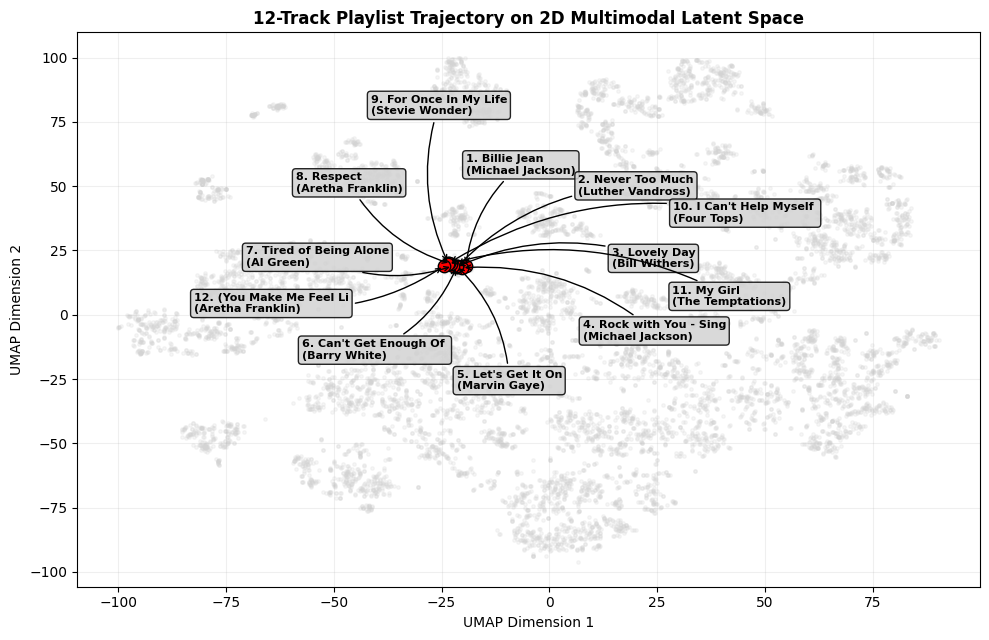

In [5]:
umap_comb = pd.read_parquet(DATA_DIR / 'similarity' / 'umap_2d_combined.parquet')


def generate_playlist(start_seed_idx: int, playlist_length: int = 5):
    current = start_seed_idx
    visited = {current}
    playlist_indices = [current]
    for _ in range(playlist_length - 1):
        recs = recommend_songs(current, top_k=15, penalize_same_artist=True)
        for candidate_idx in recs.index:
            if candidate_idx not in visited:
                playlist_indices.append(candidate_idx)
                visited.add(candidate_idx)
                current = candidate_idx
                break
    return playlist_indices


playlist = generate_playlist(start_seed_idx=653, playlist_length=12)


print("Seed track:", songs.iloc[playlist[0]]['track_name'], "by", songs.iloc[playlist[0]]['artist_names'])


plt.figure(figsize=(10, 6.5))
plt.scatter(umap_comb['proj_x'], umap_comb['proj_y'], c='lightgray', alpha=0.2, s=6, label='Global 10k Song Library')


px = umap_comb.iloc[playlist]['proj_x'].values
py = umap_comb.iloc[playlist]['proj_y'].values


plt.plot(px, py, color='crimson', linestyle='--', linewidth=2, zorder=4)
plt.scatter(px, py, color='red', s=80, edgecolors='black', zorder=5, label='Playlist Trajectory')


# Cycle through 4 main directions (+ a couple extra) to reduce overlap
offsets = [
    (0, 36), (28,28), (36, 0), (28, -28),
    (0, -48), (-36, -36), (-48, 0), (-36, 28),
    (-18, 58), (52, 16), (52, -16), (-58, -18)
]

for step, (idx, x, y) in enumerate(zip(playlist, px, py)):
    title = songs.iloc[idx]['track_name'][:20]
    artist = songs.iloc[idx]['artist_names'][:15]
    dx, dy = offsets[step % len(offsets)]
    plt.annotate(
        f"{step+1}. {title}\n({artist})",
        (x, y),
        xytext=(x + dx, y + dy),
        fontsize=8,
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="lightgray", alpha=0.85),
        arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2", color="black"),
        zorder=6
    )




plt.title("12-Track Playlist Trajectory on 2D Multimodal Latent Space", fontsize=12, fontweight='bold')
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()